# Unveiling Movie Success: A Data-Driven Exploration

## Business Understanding

### 1. Introduction: The Quest for Cinematic Insights
**Goal:** The primary business objective is to establish a successful new movie studio. 
To achieve this, the studio requires a data-driven strategy to guide its film production choices. 
The core business problem is the lack of insight into what makes a film commercially successful in the current market. 

This project aims to address this by leveraging a comprehensive dataset from multiple sources, including Box Office Mojo, IMDB, Rotten Tomatoes, TheMovieDB, and The Numbers. 
By analyzing these datasets, we will identify key characteristics of high-performing films at the box office, such as successful genres, production budgets, worldwide gross and release times. 
The final output will be a set of actionable insights and recommendations that the head of the new movie studio can use to inform their strategic decisions and increase the likelihood of producing profitable films.


**Approach**: Analyze datasets from Box Office Mojo, IMDb, Rotten Tomatoes, TheMovieDB (TMDb), and The Numbers to uncover patterns in genres, budgets, gross revenue, release timing, and critical reception.

### 2. Background of Film Industry

Talanta Studios is entering the film industry and needs a data-driven strategy to compete with established studios. This project analyzes box office trends — including genres, budgets, audience ratings, and release timing — using merged data from five major sources: IMDb, Rotten Tomatoes, Box Office Mojo, TMDb, and The Numbers. The goal is to understand what makes a movie financially successful and provide clear, actionable insights to guide Talanta’s first productions.

### 3. Business objectives

1.	Identify key metrics for movie success
2.	Characterize high-performing genres
3.	Explore the relationship between critical reception and financial success
4.	Examine the influence of production budget on profitability
5.	Analyze release trends and seasonality
6.	Analyze the influence of key creative personnel on success

## Data Source & Understanding

The analysis leverages a comprehensive dataset created by merging five different data sources and one database. 
The data is suitable for the project as it combines financial data, critical and audience reception, and key movie attributes.

***Data Sources:*** The project utilized data from Box Office Mojo (bom.movie_gross.csv), Rotten Tomatoes (rt.movie_info.tsv), TheMovieDB (tmdb.movies.csv), and The Numbers (tn.movie_budgets.csv).

***Database:*** The IMDb (im.db)

In [1]:
# importing libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import os
import sqlite3
from pathlib import Path
from scipy import stats

# Set plot style and figure size
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]


# Create visuals folder if it doesn't exist
VISUALS_DIR = Path('./visuals/EDA/rotten_tomatoes')
os.makedirs(VISUALS_DIR, exist_ok=True)

# Load the cleaned dataset
# Load the cleaned dataset
try:
    rt_combined_df_cleaned = pd.read_csv('./data/cleaned/cleaned_merged_reviewinfo')
except FileNotFoundError:
    print("Error: Dataset file not found at './data/cleaned/rt_combined_df_cleaned.csv'")
    exit(1)


In [2]:
# loading data sets
bom_df = pd.read_csv("./data/bom.movie_gross.csv.gz")
rt_movie_info_df = pd.read_csv("./data/rt.movie_info.tsv.gz", sep= '\t', encoding= 'latin1')

df_rt_reviews = pd.read_csv("./data/rt.reviews.tsv.gz", sep= '\t', encoding= 'latin1') 
df_tmdb_movies = pd.read_csv("./data/tmdb.movies.csv.gz")
df_tn_budgets = pd.read_csv("./data/tn.movie_budgets.csv.gz")

# previewing each
for name, df in [('Box office mojo', bom_df), ('Rotten tomatoes Reviews', df_rt_reviews), ('Rotten tomatoes movie info', rt_movie_info_df),
                 ('The movie DB',df_tmdb_movies), ('The numbers', df_tn_budgets)]:
    print(f"\n{name} Sample:")
    print(df.head())
    print(df.info())


Box office mojo Sample:
                                         title studio  domestic_gross  \
0                                  Toy Story 3     BV     415000000.0   
1                   Alice in Wonderland (2010)     BV     334200000.0   
2  Harry Potter and the Deathly Hallows Part 1     WB     296000000.0   
3                                    Inception     WB     292600000.0   
4                          Shrek Forever After   P/DW     238700000.0   

  foreign_gross  year  
0     652000000  2010  
1     691300000  2010  
2     664300000  2010  
3     535700000  2010  
4     513900000  2010  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year       

### Data understanding of each dataframe

#### Box office mojo dataset(movie_gross)


In [3]:
# checking the shape
bom_df = pd.read_csv("./data/bom.movie_gross.csv.gz")
bom_df.shape

(3387, 5)

In [4]:
# checking the info
bom_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


**Observation**
Total rows: 3387 movies

Columns: 5 - ***title***, ***studio***, ***domestic gross***, ***foreign gross***, and ***year***.

The dataset is mostly complete with title and year having no missing values

The column with more missing values is foreign gross followed by domestic gross and lastly studio.

foreign gross is stored as object instead of float, likely due to formatting issues.

#### Reviewing Rotten Tomatoes dataset 


In [5]:
# Inspect Rotten Tomatoes reviews dataset for metadata and missing values
rt_reviews_df=pd.read_csv("./data/rt.reviews.tsv.gz", sep= '\t', encoding= 'latin1') 
rt_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54432 entries, 0 to 54431
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          54432 non-null  int64 
 1   review      48869 non-null  object
 2   rating      40915 non-null  object
 3   fresh       54432 non-null  object
 4   critic      51710 non-null  object
 5   top_critic  54432 non-null  int64 
 6   publisher   54123 non-null  object
 7   date        54432 non-null  object
dtypes: int64(2), object(6)
memory usage: 3.3+ MB


In [6]:
# checking missing values
rt_reviews_df.isna().sum()

id                0
review         5563
rating        13517
fresh             0
critic         2722
top_critic        0
publisher       309
date              0
dtype: int64

***Observation***
Total rows: 54,432 reviews

Columns: 8 including id, review, rating, fresh, critic, top_critic, publisher, and date

All rows have id, fresh, top_critic, and date

missing values are significant in some columns

review: 5563 missing values

rating: 13517 missing

rating: 13517 missing

publisher: 309 missing values

Date column can be converted to date-time format

#### Reviewing Rotten Tomatoes dataset (movie_info)


In [7]:
# Inspect TheMovieDB dataset for metadata
rt_movie_info_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id            1560 non-null   int64 
 1   synopsis      1498 non-null   object
 2   rating        1557 non-null   object
 3   genre         1552 non-null   object
 4   director      1361 non-null   object
 5   writer        1111 non-null   object
 6   theater_date  1201 non-null   object
 7   dvd_date      1201 non-null   object
 8   currency      340 non-null    object
 9   box_office    340 non-null    object
 10  runtime       1530 non-null   object
 11  studio        494 non-null    object
dtypes: int64(1), object(11)
memory usage: 146.4+ KB


In [8]:
# checking missing values
rt_movie_info_df.isna().sum()

id                 0
synopsis          62
rating             3
genre              8
director         199
writer           449
theater_date     359
dvd_date         359
currency        1220
box_office      1220
runtime           30
studio          1066
dtype: int64

***Observation***
Total rows: 1560 movie reviews

Columns: 12- id, synopsis, rating, genre, director, writer, theater_date, dvd_date, currency, box_office, runtime, studio

Columns like id, rating, genre, and runtime are mostly complete.

Missing values are significant in several columns

synopsis: 62 missing

director: 199 missing

writer: 449 missing

theater_date and dvd_date: both have 359 missing

box_office and currency: 1220 missing

studio: 1066 missing, most data missing

Theater_date, dvd_date, and runtime should be converted to datetime or numeric for analysis.

box_office and currency are object types need to be converted to numeric

#### Reviewing the movie DB dataset (tmdb movie df)


In [9]:
# Inspect The Numbers dataset for metadata
df_tmdb_movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26517 entries, 0 to 26516
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         26517 non-null  int64  
 1   genre_ids          26517 non-null  object 
 2   id                 26517 non-null  int64  
 3   original_language  26517 non-null  object 
 4   original_title     26517 non-null  object 
 5   popularity         26517 non-null  float64
 6   release_date       26517 non-null  object 
 7   title              26517 non-null  object 
 8   vote_average       26517 non-null  float64
 9   vote_count         26517 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.0+ MB


***Observation***
Total movies: 26,517

Columns: 10 - includes title info, ratings, language, and release_date

No missing values across any of the 10 columns - very clean.

unnamed column needs to be dropped

release_date should be converted to datetime

#### Reviewing The Numbers dataset (movie budgets df)


In [10]:
df_tn_budgets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5782 entries, 0 to 5781
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   id                 5782 non-null   int64 
 1   release_date       5782 non-null   object
 2   movie              5782 non-null   object
 3   production_budget  5782 non-null   object
 4   domestic_gross     5782 non-null   object
 5   worldwide_gross    5782 non-null   object
dtypes: int64(1), object(5)
memory usage: 271.2+ KB


***Observation***
Total entries: 5,782 movies

Columns: 6 - focused on financial and release information

Complete data (no missing entries) across all columns

Key financial metrics included:

production_budget

domestic_gross

worldwide_gross

release_date is present, enabling time-based trend analysis

#### loading the sqlite database


In [11]:
# Connect to the IMDb SQLite database and list available tables
con = sqlite3.connect("./data/im.db") #creating a connection

# previewing the schema
pd.read_sql("""
SELECT name
    FROM sqlite_master
WHERE type= "table";
""", con)

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


#### selecting movie_basics and movie_ratings tables


In [12]:
# Query the movie_basics table from the IMDb database and display the last few rows
query= """
SELECT *
FROM movie_basics
"""
pd.read_sql(query, con).tail()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None
146143,tt9916754,Chico Albuquerque - Revelações,Chico Albuquerque - Revelações,2013,NaN,Documentary


In [13]:
# joining the two tables using movie_id
query= """
SELECT *
FROM movie_basics
LEFT JOIN movie_ratings
USING(movie_id);
"""
movie_basics_rating_df= pd.read_sql(query, con)
movie_basics_rating_df.tail()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres,averagerating,numvotes
146139,tt9916538,Kuambil Lagi Hatiku,Kuambil Lagi Hatiku,2019,123.0,Drama,NaN,NaN
146140,tt9916622,Rodolpho Teóphilo - O Legado de um Pioneiro,Rodolpho Teóphilo - O Legado de um Pioneiro,2015,NaN,Documentary,NaN,NaN
146141,tt9916706,Dankyavar Danka,Dankyavar Danka,2013,NaN,Comedy,NaN,NaN
146142,tt9916730,6 Gunn,6 Gunn,2017,116.0,None,NaN,NaN
146143,tt9916754,Chico Albuquerque - Revelações,Chico Albuquerque - Revelações,2013,NaN,Documentary,NaN,NaN


## Data cleaning & Validation

### 1.0 Box office mojo dataset

In [14]:
# creating a working copy 
bom_clean_df= bom_df.copy()
bom_clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3387 entries, 0 to 3386
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           3387 non-null   object 
 1   studio          3382 non-null   object 
 2   domestic_gross  3359 non-null   float64
 3   foreign_gross   2037 non-null   object 
 4   year            3387 non-null   int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 132.4+ KB


In [15]:
# checking for duplicates
duplicated_rows= bom_clean_df.duplicated()
duplicated_rows.sum()

0

In [16]:
# cleaning the bom_df(movie_gross) from Box office mojo dataset
bom_clean_df.columns

Index(['title', 'studio', 'domestic_gross', 'foreign_gross', 'year'], dtype='object')

In [17]:
# cleaning title column
# checking for duplicates
key_columns= ['title', 'year']
dupl_row= bom_clean_df[bom_clean_df.duplicated(subset= key_columns, keep= False)]
dupl_row

,title,studio,domestic_gross,foreign_gross,year


There are no duplicates

#### 1.1 Movie Budget dataset

***Convert currency strings to numeric, and also parsing dates***

In [18]:
# Clean financial columns in df_tn_budgets
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
    if col in df_tn_budgets.columns:
        # Remove dollar signs and commas, and convert to numeric
        df_tn_budgets[col] = df_tn_budgets[col].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        df_tn_budgets[col] = pd.to_numeric(df_tn_budgets[col], errors='coerce')

# Verify data types and check for any remaining non-numeric values
print("Data types after cleaning df_tn_budgets:")
print(df_tn_budgets[['production_budget', 'domestic_gross', 'worldwide_gross']].dtypes)
print("\nAny non-numeric values after cleaning:")
for col in ['production_budget', 'domestic_gross', 'worldwide_gross']:
    print(f"{col} non-numeric values: {df_tn_budgets[col].isna().sum()}")

Data types after cleaning df_tn_budgets:
production_budget    int64
domestic_gross       int64
worldwide_gross      int64
dtype: object

Any non-numeric values after cleaning:
production_budget non-numeric values: 0
domestic_gross non-numeric values: 0
worldwide_gross non-numeric values: 0


In [19]:
# Convert release_date to datetime and extract release year
df_tn_budgets['release_date'] = pd.to_datetime(df_tn_budgets['release_date'], errors='coerce')

In [20]:
df_tn_budgets['release_year'] = df_tn_budgets['release_date'].dt.year

In [21]:
# Filter for movies released after 2010
df_tn_budgets = df_tn_budgets[df_tn_budgets['release_year'] > 2010]

In [22]:
df_tn_budgets.release_year.value_counts()

2015    338
2014    255
2011    254
2013    238
2012    235
2016    219
2017    168
2018    143
2019     67
2020      3
Name: release_year, dtype: int64

In [23]:
print("df_tn_budgets after cleaning:")
print()
df_tn_budgets.info()

df_tn_budgets after cleaning:

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1920 entries, 1 to 5780
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   id                 1920 non-null   int64         
 1   release_date       1920 non-null   datetime64[ns]
 2   movie              1920 non-null   object        
 3   production_budget  1920 non-null   int64         
 4   domestic_gross     1920 non-null   int64         
 5   worldwide_gross    1920 non-null   int64         
 6   release_year       1920 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(1)
memory usage: 120.0+ KB


In [24]:
df_tn_budgets.to_csv('./data/cleaned/cleaned_df_tn_budgets')

#### 1.2 Rotten tomatoes movie info dataset

In [25]:
# Clean Rotten Tomatoes movie info dataset: convert box_office to numeric, theater_date to datetime
print("\nCleaning df_rt_info...")
if 'box_office' in rt_movie_info_df.columns and rt_movie_info_df['box_office'].dtype == 'object':
        rt_movie_info_df['box_office'] = rt_movie_info_df['box_office'].astype(str).str.replace('$', '', regex=False).str.replace(',', '', regex=False)
        rt_movie_info_df['box_office'] = pd.to_numeric(rt_movie_info_df['box_office'], errors='coerce')
if 'theater_date' in rt_movie_info_df.columns:
        rt_movie_info_df['theater_date'] = pd.to_datetime(rt_movie_info_df['theater_date'], errors='coerce')


Cleaning df_rt_info...


In [26]:
# Fill missing categorical values with 'Unknown'
for col in ['synopsis', 'rating', 'genre', 'director', 'writer', 'studio']:
        if col in rt_movie_info_df.columns:
            initial_missing_count = rt_movie_info_df[col].isnull().sum()
            if initial_missing_count > 0:
                rt_movie_info_df[col] = rt_movie_info_df[col].fillna('Unknown')
                print(f"Filled {initial_missing_count} missing '{col}' values with 'Unknown'.")

Filled 62 missing 'synopsis' values with 'Unknown'.
Filled 3 missing 'rating' values with 'Unknown'.
Filled 8 missing 'genre' values with 'Unknown'.
Filled 199 missing 'director' values with 'Unknown'.
Filled 449 missing 'writer' values with 'Unknown'.
Filled 1066 missing 'studio' values with 'Unknown'.


In [27]:
# Clean runtime by removing ' minutes' and converting to numeric, filling missing with median
if 'runtime' in rt_movie_info_df.columns:
        # First, remove " minutes" string if present
        if rt_movie_info_df['runtime'].dtype == 'object':
            rt_movie_info_df['runtime'] = rt_movie_info_df['runtime'].astype(str).str.replace(' minutes', '', regex=False)
        # Convert to numeric, coercing errors (e.g., non-numeric strings) to NaN
        rt_movie_info_df['runtime'] = pd.to_numeric(rt_movie_info_df['runtime'], errors='coerce')
        initial_missing_runtime = rt_movie_info_df['runtime'].isnull().sum()
        if initial_missing_runtime > 0:
            median_runtime = rt_movie_info_df['runtime'].median()
            rt_movie_info_df['runtime'] = rt_movie_info_df['runtime'].fillna(median_runtime)
            print(f"Filled {initial_missing_runtime} missing 'runtime' values with median ({median_runtime}).")

Filled 30 missing 'runtime' values with median (100.0).


In [28]:
print("df_rt_info after cleaning:")
rt_movie_info_df.info()

df_rt_info after cleaning:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            1560 non-null   int64         
 1   synopsis      1560 non-null   object        
 2   rating        1560 non-null   object        
 3   genre         1560 non-null   object        
 4   director      1560 non-null   object        
 5   writer        1560 non-null   object        
 6   theater_date  1201 non-null   datetime64[ns]
 7   dvd_date      1201 non-null   object        
 8   currency      340 non-null    object        
 9   box_office    340 non-null    float64       
 10  runtime       1560 non-null   float64       
 11  studio        1560 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(8)
memory usage: 146.4+ KB


In [29]:
print("Missing values after cleaning:\n", rt_movie_info_df.isnull().sum())

Missing values after cleaning:
 id                 0
synopsis           0
rating             0
genre              0
director           0
writer             0
theater_date     359
dvd_date         359
currency        1220
box_office      1220
runtime            0
studio             0
dtype: int64


In [30]:
rt_movie_info_df.rating.value_counts()

R          521
NR         503
PG         240
PG-13      235
G           57
Unknown      3
NC17         1
Name: rating, dtype: int64

In [31]:
df_rt_info = rt_movie_info_df.drop(["theater_date", "dvd_date","currency","box_office"], axis=1)

In [32]:
df_rt_info.to_csv('./data/cleaned/cleaned_df_rt_info')

#### 1.3 Rotten tomatoes reviews dataset

In [33]:
# Clean Rotten Tomatoes reviews dataset: convert date to datetime, fill missing reviews
print("\nCleaning df_rt_reviews...")
if 'date' in df_rt_reviews.columns:
        df_rt_reviews['date'] = pd.to_datetime(df_rt_reviews['date'], errors='coerce')


Cleaning df_rt_reviews...


In [34]:
if 'review' in df_rt_reviews.columns:
        initial_missing_review = df_rt_reviews['review'].isnull().sum()
        if initial_missing_review > 0:
            df_rt_reviews['review'] = df_rt_reviews['review'].fillna('No Review Text')
            print(f"Filled {initial_missing_review} missing 'review' values with 'No Review Text'.")

Filled 5563 missing 'review' values with 'No Review Text'.


In [35]:
# Check for duplicates based on key columns
if all(col in df_rt_reviews.columns for col in ['id', 'review', 'critic','publisher', 'date']):
        initial_rows_rt_reviews = len(df_rt_reviews)
        df_rt_reviews.drop_duplicates(subset=['id', 'review', 'critic','publisher', 'date'])
        print(f"df_rt_reviews: Removed {initial_rows_rt_reviews - len(df_rt_reviews)} duplicates based on 'id', 'review','publisher', 'critic', and 'date'.")
else:
        print("df_rt_reviews: Skipping duplicate check due to missing 'id', 'review', 'critic', or 'date' columns.")

df_rt_reviews: Removed 0 duplicates based on 'id', 'review','publisher', 'critic', and 'date'.


In [36]:
df_rt_reviews.drop(columns='rating', inplace=True)

In [37]:
df_rt_reviews.fresh.value_counts()

fresh     33035
rotten    21397
Name: fresh, dtype: int64

In [38]:
# Drop rating column and fill missing critic/publisher with 'Unknown'
for col in ['critic', 'publisher']:
        if col in df_rt_reviews.columns:
            initial_missing_count = df_rt_reviews[col].isnull().sum()
            if initial_missing_count > 0:
                df_rt_reviews[col] = df_rt_reviews[col].fillna('Unknown ' + col.capitalize())
                print(f"Filled {initial_missing_count} missing '{col}' values with 'Unknown {col.capitalize()}'.")

Filled 2722 missing 'critic' values with 'Unknown Critic'.
Filled 309 missing 'publisher' values with 'Unknown Publisher'.


In [39]:
print("df_rt_reviews after cleaning:")
print()
print(df_rt_reviews.info())
print()
print(f"Duplicates:", df_rt_reviews.duplicated().sum())

df_rt_reviews after cleaning:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54432 entries, 0 to 54431
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   id          54432 non-null  int64         
 1   review      54432 non-null  object        
 2   fresh       54432 non-null  object        
 3   critic      54432 non-null  object        
 4   top_critic  54432 non-null  int64         
 5   publisher   54432 non-null  object        
 6   date        54432 non-null  datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(4)
memory usage: 2.9+ MB
None

Duplicates: 25


In [40]:
print("Missing values after cleaning:\n", df_rt_reviews.isnull().sum())

Missing values after cleaning:
 id            0
review        0
fresh         0
critic        0
top_critic    0
publisher     0
date          0
dtype: int64


In [41]:
df_rt_reviews.to_csv("./data/cleaned/cleaned_df_rt_reviews")

#### 1.4 The Movie Database dataset

In [42]:
df_tmdb_movies['release_date'] = pd.to_datetime(df_tmdb_movies['release_date'], errors='coerce')
df_tmdb_movies['release_year'] = df_tmdb_movies['release_date'].dt.year

In [43]:
print("df_tmdb_movies after cleaning:")
print()
df_tmdb_movies.info()

df_tmdb_movies after cleaning:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26517 entries, 0 to 26516
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         26517 non-null  int64         
 1   genre_ids          26517 non-null  object        
 2   id                 26517 non-null  int64         
 3   original_language  26517 non-null  object        
 4   original_title     26517 non-null  object        
 5   popularity         26517 non-null  float64       
 6   release_date       26517 non-null  datetime64[ns]
 7   title              26517 non-null  object        
 8   vote_average       26517 non-null  float64       
 9   vote_count         26517 non-null  int64         
 10  release_year       26517 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4), object(4)
memory usage: 2.2+ MB


In [44]:
print("Missing values after cleaning:\n", df_tmdb_movies.isnull().sum())

Missing values after cleaning:
 Unnamed: 0           0
genre_ids            0
id                   0
original_language    0
original_title       0
popularity           0
release_date         0
title                0
vote_average         0
vote_count           0
release_year         0
dtype: int64


In [45]:
df_tmdb_movies.to_csv("./data/cleaned/cleaned_df_tmdb_movies")

#### 1.5 Connection to the database

In [46]:
conn = sqlite3.connect('./data/im.db')
pd.read_sql('''
SELECT name FROM sqlite_master
    WHERE type = 'table'
''',conn)

,name
0,movie_basics
1,directors
2,known_for
3,movie_akas
4,movie_ratings
5,persons
6,principals
7,writers


In [47]:
movie_basics_df = pd.read_sql("""
    SELECT * FROM movie_basics
""",conn)

movie_basics_df.head()

,movie_id,primary_title,original_title,start_year,runtime_minutes,genres
0,tt0063540,Sunghursh,Sunghursh,2013,175.0,"Action,Crime,Drama"
1,tt0066787,One Day Before the Rainy Season,Ashad Ka Ek Din,2019,114.0,"Biography,Drama"
2,tt0069049,The Other Side of the Wind,The Other Side of the Wind,2018,122.0,Drama
3,tt0069204,Sabse Bada Sukh,Sabse Bada Sukh,2018,NaN,"Comedy,Drama"
4,tt0100275,The Wandering Soap Opera,La Telenovela Errante,2017,80.0,"Comedy,Drama,Fantasy"


In [48]:
# Query movie_basics table from IMDb database and display first few rows
movie_ratings_df = pd.read_sql("""
       SELECT * FROM movie_ratings
""",conn)

movie_ratings_df

,movie_id,averagerating,numvotes
0,tt10356526,8.3,31
1,tt10384606,8.9,559
2,tt1042974,6.4,20
3,tt1043726,4.2,50352
4,tt1060240,6.5,21
...,...,...,...
73851,tt9805820,8.1,25
73852,tt9844256,7.5,24
73853,tt9851050,4.7,14
73854,tt9886934,7.0,5


####  Merging and cleaning the database data


In [49]:
movie_with_ratings = pd.merge(movie_ratings_df, movie_basics_df, left_on='movie_id', right_on='movie_id')
movie_with_ratings.head()

,movie_id,averagerating,numvotes,primary_title,original_title,start_year,runtime_minutes,genres
0,tt10356526,8.3,31,Laiye Je Yaarian,Laiye Je Yaarian,2019,117.0,Romance
1,tt10384606,8.9,559,Borderless,Borderless,2019,87.0,Documentary
2,tt1042974,6.4,20,Just Inès,Just Inès,2010,90.0,Drama
3,tt1043726,4.2,50352,The Legend of Hercules,The Legend of Hercules,2014,99.0,"Action,Adventure,Fantasy"
4,tt1060240,6.5,21,Até Onde?,Até Onde?,2011,73.0,"Mystery,Thriller"


In [50]:
movie_with_ratings.isnull().sum()

movie_id              0
averagerating         0
numvotes              0
primary_title         0
original_title        0
start_year            0
runtime_minutes    7620
genres              804
dtype: int64

In [51]:
movie_with_ratings = movie_with_ratings.dropna()

In [52]:
movie_with_ratings.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 65720 entries, 0 to 73855
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   movie_id         65720 non-null  object 
 1   averagerating    65720 non-null  float64
 2   numvotes         65720 non-null  int64  
 3   primary_title    65720 non-null  object 
 4   original_title   65720 non-null  object 
 5   start_year       65720 non-null  int64  
 6   runtime_minutes  65720 non-null  float64
 7   genres           65720 non-null  object 
dtypes: float64(2), int64(2), object(4)
memory usage: 4.5+ MB


In [53]:
movie_with_ratings.to_csv("./data/cleaned/cleaned_merged_movie_wih_ratings")

### 2.0 Feature Engineering

In [54]:
# Compute Review_Count and Freshness_Score
review_counts = df_rt_reviews.groupby('id').agg(
    Review_Count=('fresh', 'count'),
    Freshness_Score=('fresh', lambda x: (x == 'fresh').sum() / len(x))
).reset_index()

In [55]:
review_counts.columns = review_counts.columns.str.lower()

In [56]:
df_rt_combined = pd.merge(df_rt_info, review_counts, on='id', how='left')
df_rt_combined.isnull().sum()

id                   0
synopsis             0
rating               0
genre                0
director             0
writer               0
runtime              0
studio               0
review_count       425
freshness_score    425
dtype: int64

In [57]:
# Fill missing review_count with 0
df_rt_combined['review_count'] = df_rt_combined['review_count'].fillna(0)

# Fill missing freshness_score with median
median_fresh = df_rt_combined['freshness_score'].median()
df_rt_combined['freshness_score'] = df_rt_combined['freshness_score'].fillna(median_fresh)

In [58]:
# Standardize column names to lowercase
df_rt_combined.columns = df_rt_combined.columns.str.lower()

In [59]:
df_rt_combined.to_csv("./data/cleaned/cleaned_merged_reviewinfo")

#### Merging the movies database and the movie budget

In [60]:
#for differentiation I renamed the 'title' to 'tmdb_title' to avoid problems when merging
df_tmdb_movies.rename(columns={'title': 'tmdb_title'}, inplace=True)

In [61]:
#Renamed movie in tn_budget for easy understanding when merging with tmdb
df_tn_budgets.rename(columns={'movie': 'title'}, inplace=True)

/home/capt/.conda/envs/learn-env/lib/python3.8/site-packages/pandas/core/frame.py:4296: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  return super().rename(


In [62]:
# Standardize title fields in both datasets
df_tn_budgets['title_clean'] = df_tn_budgets['title'].str.lower().str.strip().str.replace(r'[^\w\s]', '', regex=True)
df_tmdb_movies['tmdb_title_clean'] = df_tmdb_movies['tmdb_title'].str.lower().str.strip().str.replace(r'[^\w\s]', '', regex=True)
movie_with_ratings['primary_title_clean'] = movie_with_ratings['primary_title'].str.lower().str.strip().str.replace(r'[^\w\s]', '', regex=True)
# # Merge on the cleaned titles
merged = pd.merge(df_tn_budgets, df_tmdb_movies, left_on=['title_clean'], right_on=['tmdb_title_clean'], how='left')

<ipython-input-62-74a1eddc8c87>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tn_budgets['title_clean'] = df_tn_budgets['title'].str.lower().str.strip().str.replace(r'[^\w\s]', '', regex=True)


In [63]:
# Financial and temporal features
merged['Profit'] = merged['worldwide_gross'] - merged['production_budget']
merged['ROI'] = merged['Profit'] / merged['production_budget']
merged['Domestic_vs_Worldwide_Ratio'] = merged['domestic_gross'] / merged['worldwide_gross']
merged['Release_Month'] = merged['release_date_x'].dt.month
merged['Day_of_Week'] = merged['release_date_x'].dt.day_name()
merged['foreign_gross'] = merged['worldwide_gross'] - merged['domestic_gross']

In [64]:
merged.isnull().sum()

id_x                             0
release_date_x                   0
title                            0
production_budget                0
domestic_gross                   0
worldwide_gross                  0
release_year_x                   0
title_clean                      0
Unnamed: 0                     352
genre_ids                      352
id_y                           352
original_language              352
original_title                 352
popularity                     352
release_date_y                 352
tmdb_title                     352
vote_average                   352
vote_count                     352
release_year_y                 352
tmdb_title_clean               352
Profit                           0
ROI                              0
Domestic_vs_Worldwide_Ratio    279
Release_Month                    0
Day_of_Week                      0
foreign_gross                    0
dtype: int64

In [65]:
# Drop suffix columns and low-value metadata
low_value_cols = [
    'id_y', 'tmdb_title', 'original_title', 'original_language',
    'release_date_y', 'release_date_x','foreign_gross', 'tmdb_title_clean', 'release_year_y',
    'title'
   ,'Unnamed: 0'
]
merged.drop(columns=low_value_cols, errors='ignore', inplace=True)
merged.head()

,id_x,production_budget,domestic_gross,worldwide_gross,release_year_x,title_clean,genre_ids,popularity,vote_average,vote_count,Profit,ROI,Domestic_vs_Worldwide_Ratio,Release_Month,Day_of_Week
0,2,410600000,241063875,1045663875,2011,pirates of the caribbean on stranger tides,"[12, 28, 14]",30.579,6.4,8571.0,635063875,1.546673,0.230537,5,Friday
1,3,350000000,42762350,149762350,2019,dark phoenix,NaN,NaN,NaN,NaN,-200237650,-0.572108,0.285535,6,Friday
2,4,330600000,459005868,1403013963,2015,avengers age of ultron,"[28, 12, 878]",44.383,7.3,13457.0,1072413963,3.243841,0.327157,5,Friday
3,5,317000000,620181382,1316721747,2017,star wars ep viii the last jedi,NaN,NaN,NaN,NaN,999721747,3.153696,0.471004,12,Friday
4,6,306000000,936662225,2053311220,2015,star wars ep vii the force awakens,NaN,NaN,NaN,NaN,1747311220,5.710167,0.456172,12,Friday


In [66]:
merged.columns = merged.columns.str.lower()

In [67]:
merged = merged[merged['domestic_vs_worldwide_ratio'].notnull()]

In [68]:
merged.isnull().sum()

id_x                             0
production_budget                0
domestic_gross                   0
worldwide_gross                  0
release_year_x                   0
title_clean                      0
genre_ids                      250
popularity                     250
vote_average                   250
vote_count                     250
profit                           0
roi                              0
domestic_vs_worldwide_ratio      0
release_month                    0
day_of_week                      0
dtype: int64

In [69]:
merged.to_csv('./data/cleaned/merged_tn_tmdb')

#### Director and Writer Metrics


In [70]:
review_metrics = df_rt_reviews.groupby('id').agg(
    review_count=('fresh', 'count'),
    freshness_score=('fresh', lambda x: (x == 'fresh').sum() / len(x))
).reset_index()

In [71]:
# Merge review metrics with director and writer
review_metrics_full = pd.merge(df_rt_info[['id', 'director', 'writer']], review_metrics, on='id', how='left')

In [72]:
# Group by director
director_metrics = review_metrics_full.groupby('director').agg(
    director_avg_freshness=('freshness_score', 'mean'),
    director_avg_reviews=('review_count', 'mean'),
    director_movie_count=('id', 'count')
).reset_index()

# Group by writer
writer_metrics = review_metrics_full.groupby('writer').agg(
    writer_avg_freshness=('freshness_score', 'mean'),
    writer_avg_reviews=('review_count', 'mean'),
    writer_movie_count=('id', 'count')
).reset_index()

In [73]:
director_metrics.isnull().sum()

director                    0
director_avg_freshness    282
director_avg_reviews      282
director_movie_count        0
dtype: int64

In [74]:
top_directors_by_reviews = director_metrics.sort_values(by='director_avg_reviews', ascending=False).head(10)
top_directors_by_reviews

,director,director_avg_freshness,director_avg_reviews,director_movie_count
659,Martin McDonagh,0.911243,338.0,1
625,Luca Guadagnino,0.949091,275.0,1
709,Michel Hazanavicius,0.961538,260.0,1
493,Joel Coen|Ethan Coen,0.926923,260.0,1
76,Ava DuVernay,0.988372,258.0,1
727,Morten Tyldum,0.896414,251.0,1
678,Mel Gibson,0.485944,249.0,1
354,Guillermo del Toro,0.717300,237.0,1
1002,Steven Soderbergh,0.926724,232.0,1
935,Sam Mendes,0.795158,218.5,2


In [75]:
top_writers_by_reviews = writer_metrics.sort_values(by='writer_avg_reviews', ascending=False).head(10)
top_writers_by_reviews

,writer,writer_avg_freshness,writer_avg_reviews,writer_movie_count
632,Martin McDonagh,0.911243,338.0,1
423,James Ivory,0.949091,275.0,1
499,John Logan|Robert Wade|Neal Purvis,0.916031,262.0,1
672,Michel Hazanavicius,0.961538,260.0,1
302,Ethan Coen|Joel Coen,0.926923,260.0,1
759,Paul Webb,0.988372,258.0,1
789,Phyllis Nagy,0.941860,258.0,1
359,Graham Moore,0.896414,251.0,1
650,Mel Gibson|Benedict Fitzgerald,0.485944,249.0,1
770,Peter Jackson|Philippa Boyens|Guillermo del To...,0.621399,243.0,1


In [76]:
merged2 = merged.merge(movie_with_ratings, left_on='title_clean', right_on='primary_title_clean', how='inner')

In [77]:
#sort dataframe by movies alphabetically
merged2 = merged2.sort_values(by='title_clean', ascending=True)
merged2.head()

,id_x,production_budget,domestic_gross,worldwide_gross,release_year_x,title_clean,genre_ids,popularity,vote_average,vote_count,...,day_of_week,movie_id,averagerating,numvotes,primary_title,original_title,start_year,runtime_minutes,genres,primary_title_clean
1879,54,5000000,72082999,108286422,2016,10 cloverfield lane,"[53, 878, 18]",17.892,6.9,4629.0,...,Friday,tt1179933,7.2,260383,10 Cloverfield Lane,10 Cloverfield Lane,2016,103.0,"Drama,Horror,Mystery",10 cloverfield lane
1556,48,12000000,14616,14616,2015,10 days in a madhouse,[18],0.955,5.4,7.0,...,Wednesday,tt3453052,6.7,1114,10 Days in a Madhouse,10 Days in a Madhouse,2015,111.0,Drama,10 days in a madhouse
809,64,35000000,45819713,71118378,2018,12 strong,"[10752, 18, 36, 28]",13.183,5.6,1312.0,...,Friday,tt1413492,6.6,50155,12 Strong,12 Strong,2018,130.0,"Action,Drama,History",12 strong
1207,18,20000000,56671993,181025343,2013,12 years a slave,"[18, 36]",16.493,7.9,6631.0,...,Friday,tt2024544,8.1,577301,12 Years a Slave,12 Years a Slave,2013,134.0,"Biography,Drama,History",12 years a slave
2040,51,4000000,9134,47552,2014,13 sins,"[27, 53]",10.899,6.3,576.0,...,Friday,tt2059171,6.3,29550,13 Sins,13 Sins,2014,93.0,"Horror,Thriller",13 sins


In [78]:
merged2 = merged2.groupby('title_clean')
merged2 = merged2.first()

In [79]:
#for analysis purposes, change all multiple genre observations into the string "mix"
merged2.loc[merged2['genres'].str.contains(','), 'genres'] = 'mix'
merged2.head()

,id_x,production_budget,domestic_gross,worldwide_gross,release_year_x,genre_ids,popularity,vote_average,vote_count,profit,...,day_of_week,movie_id,averagerating,numvotes,primary_title,original_title,start_year,runtime_minutes,genres,primary_title_clean
title_clean,,,,,,,,,,,,,,,,,,,,,
10 cloverfield lane,54,5000000,72082999,108286422,2016,"[53, 878, 18]",17.892,6.9,4629.0,103286422,...,Friday,tt1179933,7.2,260383,10 Cloverfield Lane,10 Cloverfield Lane,2016,103.0,mix,10 cloverfield lane
10 days in a madhouse,48,12000000,14616,14616,2015,[18],0.955,5.4,7.0,-11985384,...,Wednesday,tt3453052,6.7,1114,10 Days in a Madhouse,10 Days in a Madhouse,2015,111.0,Drama,10 days in a madhouse
12 strong,64,35000000,45819713,71118378,2018,"[10752, 18, 36, 28]",13.183,5.6,1312.0,36118378,...,Friday,tt1413492,6.6,50155,12 Strong,12 Strong,2018,130.0,mix,12 strong
12 years a slave,18,20000000,56671993,181025343,2013,"[18, 36]",16.493,7.9,6631.0,161025343,...,Friday,tt2024544,8.1,577301,12 Years a Slave,12 Years a Slave,2013,134.0,mix,12 years a slave
13 sins,51,4000000,9134,47552,2014,"[27, 53]",10.899,6.3,576.0,-3952448,...,Friday,tt2059171,6.3,29550,13 Sins,13 Sins,2014,93.0,mix,13 sins


In [80]:
merged2.to_csv('./data/cleaned/merged_with_db')

### Data Validation

In [81]:
# Load the merged DataFrame (correct file path)
merged = pd.read_csv("./data/cleaned/merged_tn_tmdb")

# 1. Re-run Summary Statistics
print("--- 1. Re-run Initial Data Profiling/Summary Statistics ---")
print("\n1.1. `df.info()` - Check Data Types and Non-Null Counts:")
print(merged.info())

print("\n1.2. `df.describe()` - Summary Statistics for Numerical Columns:")
print(merged.describe())

print("\n1.3. `df.nunique()` - Number of Unique Values per Column:")
print(merged.nunique())

print("\n1.4. `df.isnull().sum()` - Check for Remaining Missing Values:")
print(merged.isnull().sum())
print("\n" + "="*50 + "\n")

--- 1. Re-run Initial Data Profiling/Summary Statistics ---

1.1. `df.info()` - Check Data Types and Non-Null Counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1960 entries, 0 to 1959
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   1960 non-null   int64  
 1   id_x                         1960 non-null   int64  
 2   production_budget            1960 non-null   int64  
 3   domestic_gross               1960 non-null   int64  
 4   worldwide_gross              1960 non-null   int64  
 5   release_year_x               1960 non-null   int64  
 6   title_clean                  1960 non-null   object 
 7   genre_ids                    1710 non-null   object 
 8   popularity                   1710 non-null   float64
 9   vote_average                 1710 non-null   float64
 10  vote_count                   1710 non-null   float64
 11  profit          

In [82]:
# Consistency Checks
print("\n2. Consistency Checks:")
inconsistent_production_budget = merged[merged['production_budget'] <= 0]
if not inconsistent_production_budget.empty:
    print(f"WARNING: Found {len(inconsistent_production_budget)} rows where production_budget is less than or equal to $0:")
    print(inconsistent_production_budget[['title_clean', 'production_budget']])
else:
    print("-> All 'production_budget' values are valid.")


2. Consistency Checks:
-> All 'production_budget' values are valid.


In [83]:
# Uniqueness Checks
print("\n2.3. Uniqueness Checks:")
if 'id_x' in merged.columns and not merged['id_x'].is_unique:
    print(f"-> WARNING: 'id_x' is NOT unique! Duplicates found:")
    print(merged[merged['id_x'].duplicated(keep=False)].sort_values('id_x'))
else:
    print("-> 'id_x' column is unique.")


2.3. Uniqueness Checks:
-> WARNING: 'id_x' is NOT unique! Duplicates found:
      Unnamed: 0  id_x  production_budget  domestic_gross  worldwide_gross  \
574          586     1           40000000        86208010        156553592   
612          624     1           40000000        18450127         20790486   
1314        1351     1           10000000        20777061         38985577   
1313        1350     1           10000000        20777061         38985577   
1857        2013     1            1000000               0            17721   
...          ...   ...                ...             ...              ...   
1416        1460   100            8000000         6758416          9266180   
754          769   100           30000000        46889293         84393749   
805          820   100           30000000          490973           648599   
1904        2115   100             450000           13486            13486   
979          999   100           20000000       111035005        

## EDA

### 1. The movies database and budget dataset

Our EDA will focus on visual comparisons using the featured columns to uncover patterns and relationships.

#### Univariate Analysis
**Objective:** Understand the distribution of key variables:
       - production budget
       
       - domestic gross
       
       - worldwide gross
       
       - ROI
       
       - Profit
       
       - Release Month
       
       - Day of Week

In [84]:
import pandas as pd
tmdbbudget_clean = pd.read_csv("./data/cleaned/tmdb.budget.csv")
tmdbbudget_clean.head(5)

,title,production_budget,domestic_gross,worldwide_gross,release_year,Profit,ROI,Domestic_vs_Worldwide_Ratio,Release_Month,Day_of_Week,foreign_gross
0,Avatar,425000000,760507625,2776345279,2009,2351345279,5.532577,0.273924,12,Friday,2015837654
1,Pirates of the Caribbean: On Stranger Tides,410600000,241063875,1045663875,2011,635063875,1.546673,0.230537,5,Friday,804600000
2,Dark Phoenix,350000000,42762350,149762350,2019,-200237650,-0.572108,0.285535,6,Friday,107000000
3,Avengers: Age of Ultron,330600000,459005868,1403013963,2015,1072413963,3.243841,0.327157,5,Friday,944008095
4,Star Wars Ep. VIII: The Last Jedi,317000000,620181382,1316721747,2017,999721747,3.153696,0.471004,12,Friday,696540365


In [85]:
tmdbbudget_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5570 entries, 0 to 5569
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   title                        5570 non-null   object 
 1   production_budget            5570 non-null   int64  
 2   domestic_gross               5570 non-null   int64  
 3   worldwide_gross              5570 non-null   int64  
 4   release_year                 5570 non-null   int64  
 5   Profit                       5570 non-null   int64  
 6   ROI                          5570 non-null   float64
 7   Domestic_vs_Worldwide_Ratio  5570 non-null   float64
 8   Release_Month                5570 non-null   int64  
 9   Day_of_Week                  5570 non-null   object 
 10  foreign_gross                5570 non-null   int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 478.8+ KB


In [86]:
# Columns to analyze
num_cols = ['production_budget', 'domestic_gross', 'worldwide_gross', 'ROI', 'Profit', 'Release_Month']
cat_cols = ['Day_of_Week']

In [87]:
# Display descriptive statistics
print("Descriptive Statistics (Numerical):")
print(tmdbbudget_clean[num_cols].describe())

print("\nDay_of_Week Value Counts:")
print(tmdbbudget_clean['Day_of_Week'].value_counts())

Descriptive Statistics (Numerical):
       production_budget  domestic_gross  worldwide_gross          ROI  \
count       5.570000e+03    5.570000e+03     5.570000e+03  5570.000000   
mean        3.367768e+07    4.536110e+07     9.960677e+07     4.097453   
std         4.301451e+07    7.047073e+07     1.810613e+08    30.073302   
min         1.100000e+03    0.000000e+00     2.600000e+01    -0.999974   
25%         6.000000e+06    3.287345e+06     7.144375e+06    -0.289318   
50%         1.915000e+07    2.046062e+07     3.365860e+07     0.905925   
75%         4.200000e+07    5.638129e+07     1.069392e+08     3.005233   
max         4.250000e+08    9.366622e+08     2.776345e+09  1799.000000   

             Profit  Release_Month  
count  5.570000e+03    5570.000000  
mean   6.592909e+07       7.029803  
std    1.515286e+08       3.458526  
min   -2.002376e+08       1.000000  
25%   -1.807113e+06       4.000000  
50%    1.231326e+07       7.000000  
75%    6.915838e+07      10.000000  
m

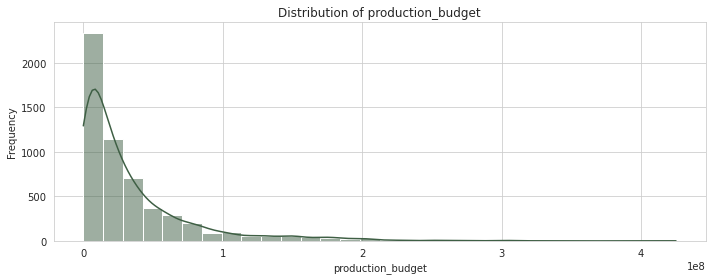

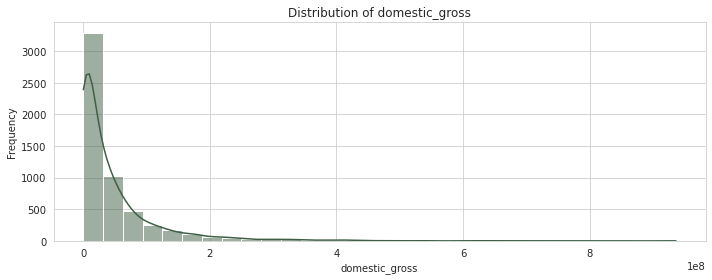

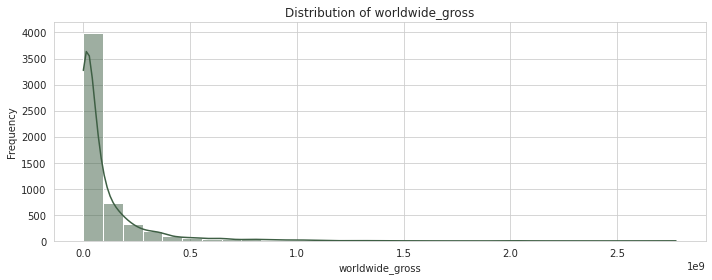

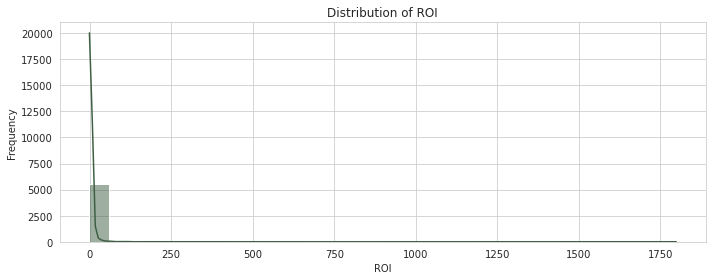

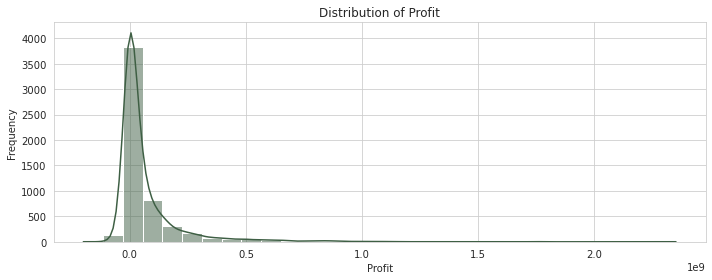

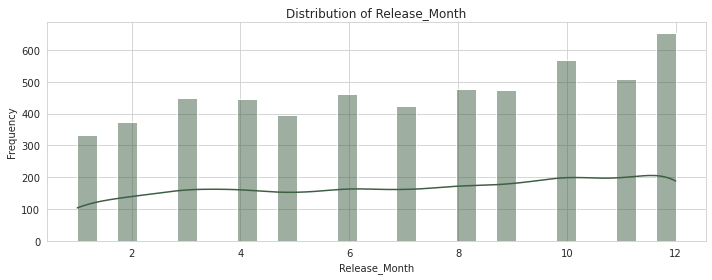

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
# Plotting histograms for numeric features
for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.histplot(tmdbbudget_clean[col], kde=True, bins=30, color='#3E5F44')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

The chart shows the distribution of production budgets for a set of movies. The data is right-skewed, meaning most movies have a relatively low production budget

The data is heavily right-skewed, with a large number of movies having a low domestic gross. The peak frequency is at the lower end of the domestic gross scale, with the number of movies decreasing sharply as the revenue increases.

The data is heavily right-skewed, indicating that a majority of movies have a relatively low worldwide gross.

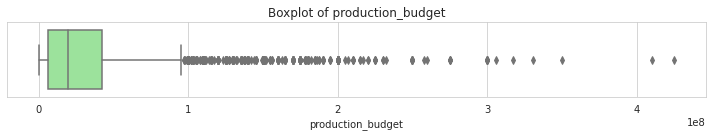

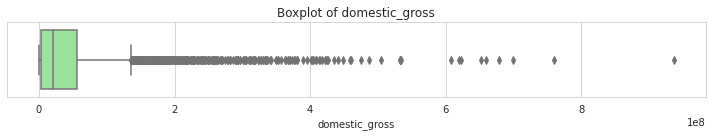

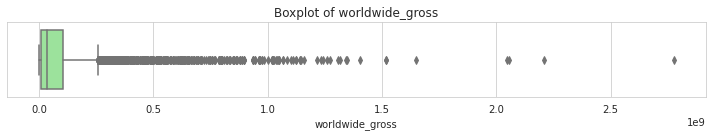

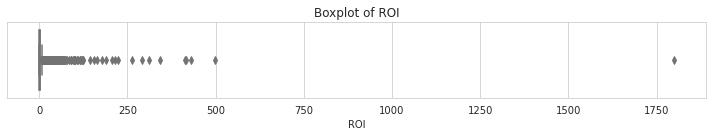

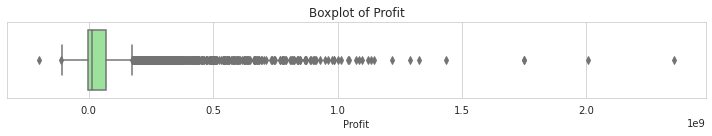

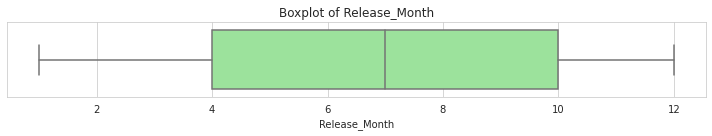

In [89]:
# Boxplots for numeric features (to detect outliers)
for col in num_cols:
    plt.figure(figsize=(10, 2))
    sns.boxplot(x=tmdbbudget_clean[col], color='lightgreen')
    plt.title(f'Boxplot of {col}')
    plt.tight_layout()
    plt.show()

The plot shows a negative correlation between the two variables, though it's not a strong linear relationship. A large number of movies with low production budgets have a wide range of ROIs, including some very high values. However, as the production budget increases, the variability in ROI decreases, and the overall ROI tends to be much lower. This suggests that while a high budget doesn't guarantee a good ROI, movies with low budgets have a higher chance of achieving a very high ROI, although they also have a high risk of performing poorly.

There appears to be a weak to moderate positive correlation between the two variables. As the production budget increases, the maximum profit also tends to increase, suggesting that higher-budget movies have the potential for greater profitability.
However, there's a huge spread of profit values for any given budget, especially at the lower end of the budget spectrum. Many movies, regardless of budget, fail to make a profit. This indicates that while a higher budget can lead to a higher potential profit ceiling, it does not guarantee profitability. The relationship is highly variable.


There is a high concentration of movies with a low ROI that have a wide range of profits, both positive and negative. As the ROI increases, the data points become much sparser. The plot indicates that movies with a very high ROI don't necessarily have the highest profit; they often have a relatively low profit in absolute terms.
This suggests that a high ROI is often associated with movies that have very low production costs, which can still generate a decent profit, while the highest profits are made by big-budget films that, while successful, don't have the astronomical ROI of their smaller-budget counterparts.


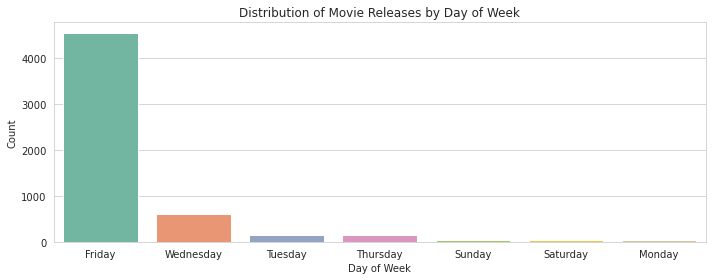

In [90]:
# Bar plot for Day_of_Week (categorical)
plt.figure(figsize=(10, 4))
sns.countplot(x='Day_of_Week', data=tmdbbudget_clean, order=tmdbbudget_clean['Day_of_Week'].value_counts().index, palette='Set2')
plt.title('Distribution of Movie Releases by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

***Finding:***

Best day: Friday releases dominate box office performance.

***Recommendation:***

Schedule major releases in summer/holiday seasons.

Maintain Friday premieres for opening weekend success.

### Bivariate Analysis 

We’ll analyze pairwise relationships like:
- Production budget vs ROI

- Production budget vs Profit

- ROI vs Profit

- Release_Month vs worldwide_gross

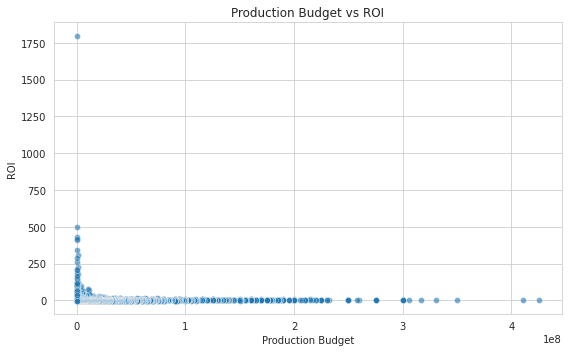

In [91]:
# Set style
# 1. production_budget vs ROI
plt.figure(figsize=(8, 5))
sns.scatterplot(x='production_budget', y='ROI', data=tmdbbudget_clean, alpha=0.6)
#sns.regplot(x='production_budget', y='ROI', data=tmdbbudget_clean, scatter=False, color='yellow')
plt.title('Production Budget vs ROI')
plt.xlabel('Production Budget')
plt.ylabel('ROI')
plt.tight_layout()
plt.show()


#### Observations

The plot shows a negative correlation between the two variables, though it's not a strong linear relationship. A large number of movies with low production budgets have a wide range of ROIs, including some very high values. However, as the production budget increases, the variability in ROI decreases, and the overall ROI tends to be much lower. This suggests that while a high budget doesn't guarantee a good ROI, movies with low budgets have a higher chance of achieving a very high ROI, although they also have a high risk of performing poorly.

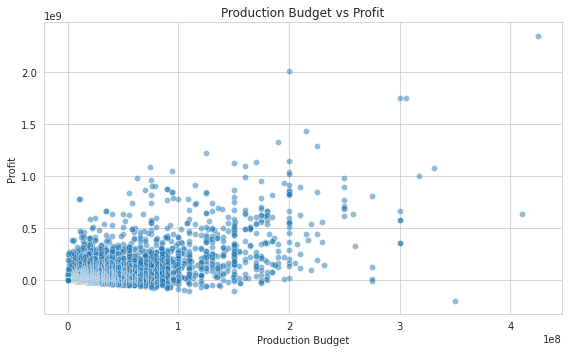

In [92]:
# 2. production_budget vs Profit
plt.figure(figsize=(8, 5))
sns.scatterplot(x='production_budget', y='Profit', data=tmdbbudget_clean, alpha=0.5)
#sns.regplot(x='production_budget', y='Profit', data=tmdbbudget_clean, scatter=False, color='red')
plt.title('Production Budget vs Profit')
plt.xlabel('Production Budget')
plt.ylabel('Profit')
plt.tight_layout()

#### Observations

There appears to be a weak to moderate positive correlation between the two variables. As the production budget increases, the maximum profit also tends to increase, suggesting that higher-budget movies have the potential for greater profitability.

However, there's a huge spread of profit values for any given budget, especially at the lower end of the budget spectrum. Many movies, regardless of budget, fail to make a profit. This indicates that while a higher budget can lead to a higher potential profit ceiling, it does not guarantee profitability. The relationship is highly variable.


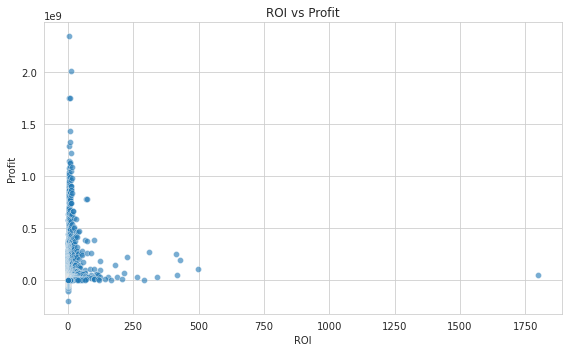

In [93]:
# 3. ROI vs Profit
plt.figure(figsize=(8, 5))
sns.scatterplot(x='ROI', y='Profit', data=tmdbbudget_clean, alpha=0.6)
#sns.regplot(x='ROI', y='Profit', data=tmdbbudget_clean, scatter=False, color='red')
plt.title('ROI vs Profit')
plt.xlabel('ROI')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

#### Observations

There is a high concentration of movies with a low ROI that have a wide range of profits, both positive and negative. As the ROI increases, the data points become much sparser. The plot indicates that movies with a very high ROI don't necessarily have the highest profit; they often have a relatively low profit in absolute terms.

This suggests that a high ROI is often associated with movies that have very low production costs, which can still generate a decent profit, while the highest profits are made by big-budget films that, while successful, don't have the astronomical ROI of their smaller-budget counterparts.


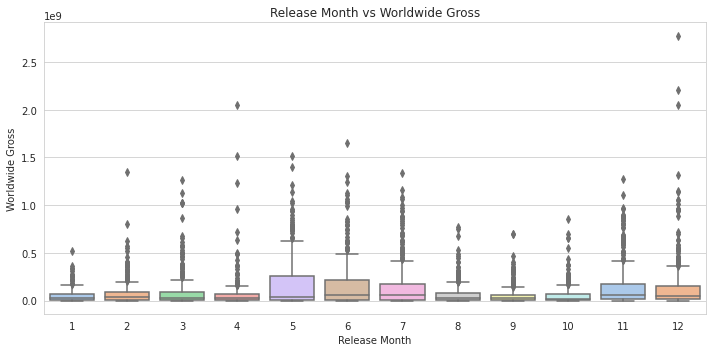

In [94]:
# 4. Release_Month vs Worldwide Gross (using boxplot to show trends)
plt.figure(figsize=(10, 5))
sns.boxplot(x='Release_Month', y='worldwide_gross', data=tmdbbudget_clean, palette='pastel')
plt.title('Release Month vs Worldwide Gross')
plt.xlabel('Release Month')
plt.ylabel('Worldwide Gross')
plt.tight_layout()
plt.show()

### Multivariate Analysis
- We’ll explore how multiple features interact together, e.g
- Correlation heatmaps among numeric variables.

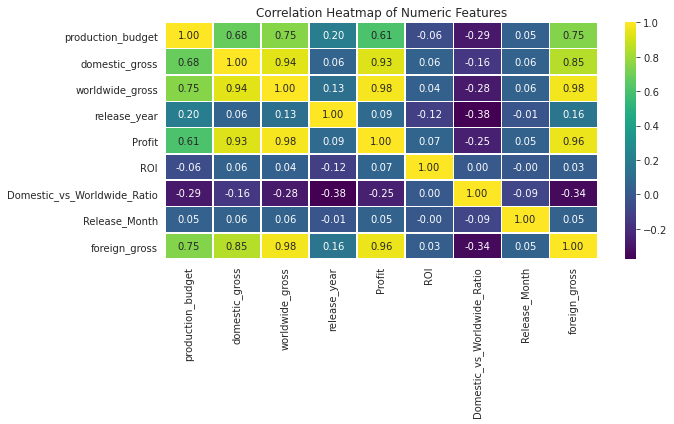

In [95]:
# Select only numeric columns
numeric_cols = tmdbbudget_clean.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = tmdbbudget_clean[numeric_cols].corr()

# Plot correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="viridis", linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

#### Observations

The matrix shows the Pearson correlation coefficient for each pair of features, with the values ranging from -1 (perfect negative correlation) to 1 (perfect positive correlation).

**Key Observations**

***Strongest Positive Correlations:***

Domestic Gross & Worldwide Gross (0.89): There is a very strong positive correlation between a movie's domestic and worldwide gross. This is expected, as movies that perform well domestically often do well internationally.

Worldwide Gross & Profit (0.93): A movie's worldwide gross is very highly correlated with its profit. This makes sense, as higher revenue directly contributes to higher profit.

Domestic Gross & Profit (0.82): Similar to the previous point, a movie's domestic gross is also strongly correlated with its profit.

***Weak or Negative Correlations:***

·   	Release Year & Worldwide Gross (-0.36): There is a weak negative correlation between release year and worldwide gross, which is somewhat counter-intuitive. This could be an artifact of the dataset or how inflation is handled

·   	Release Year & Domestic vs Worldwide Ratio (-0.36): This also shows a weak negative correlation, indicating that the ratio of domestic to worldwide gross has changed over the years in the dataset.

### 2. The rotten tomatoes movie info and reviews

This dataset is a cleaned version of the Rotten Tomatoes movie information merged with review counts and freshness scores, as prepared in our data analysis script. 

The EDA will include summary statistics, data quality checks, distribution analysis, and visualizations to uncover patterns and insights about movie characteristics and critical reception.

In [96]:
# 1. Data Overview
print("=== 1. Data Overview ===")
print("\n1.1. Data Info:")
print(rt_combined_df_cleaned.info())

print("\n1.2. First 5 Rows:")
print(rt_combined_df_cleaned.head())

print("\n1.3. Column Names:")
print(rt_combined_df_cleaned.columns.tolist())

print("\n1.4. Missing Values:")
print(rt_combined_df_cleaned.isnull().sum())

print("\n1.5. Data Shape:", rt_combined_df_cleaned.shape)
print("\n" + "="*50 + "\n")


=== 1. Data Overview ===

1.1. Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1560 entries, 0 to 1559
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       1560 non-null   int64  
 1   id               1560 non-null   int64  
 2   synopsis         1560 non-null   object 
 3   rating           1560 non-null   object 
 4   genre            1560 non-null   object 
 5   director         1560 non-null   object 
 6   writer           1560 non-null   object 
 7   runtime          1560 non-null   float64
 8   studio           1560 non-null   object 
 9   review_count     1560 non-null   float64
 10  freshness_score  1560 non-null   float64
dtypes: float64(3), int64(2), object(6)
memory usage: 134.2+ KB
None

1.2. First 5 Rows:
   Unnamed: 0  id                                           synopsis rating  \
0           0   1  This gritty, fast-paced, and innovative police...      R   
1     

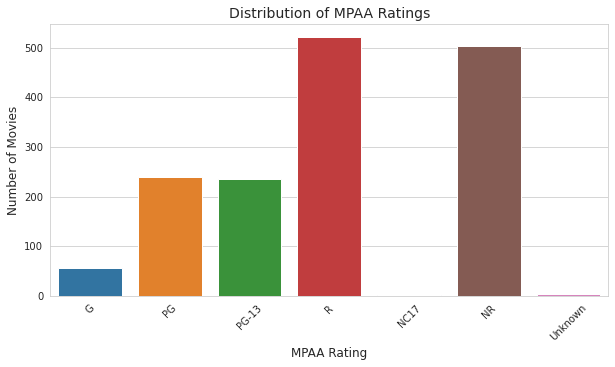

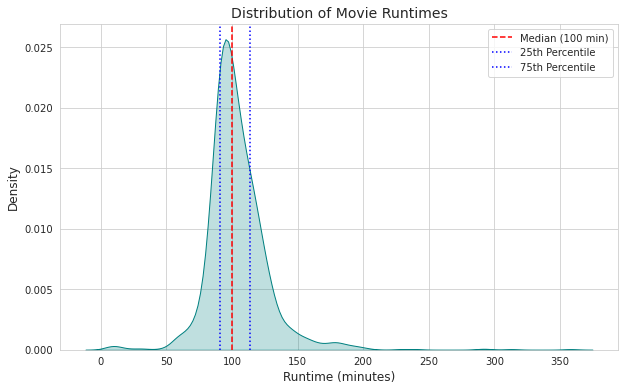

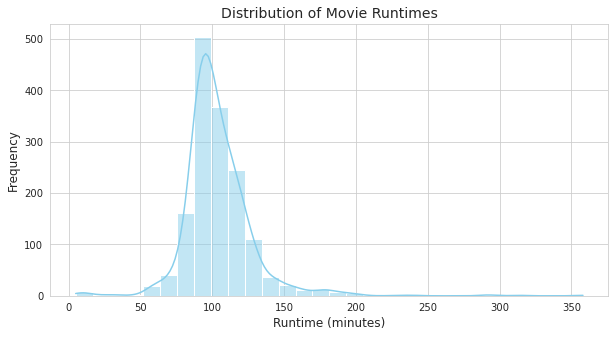

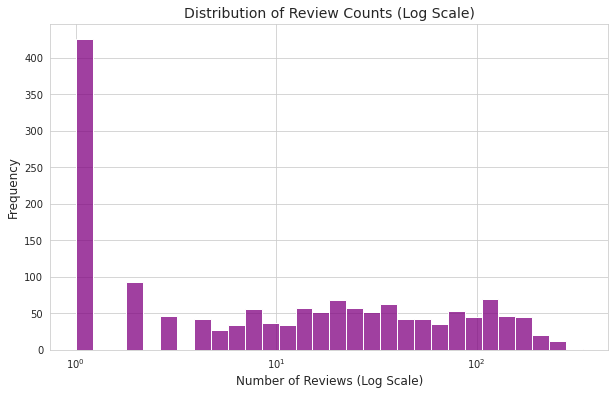

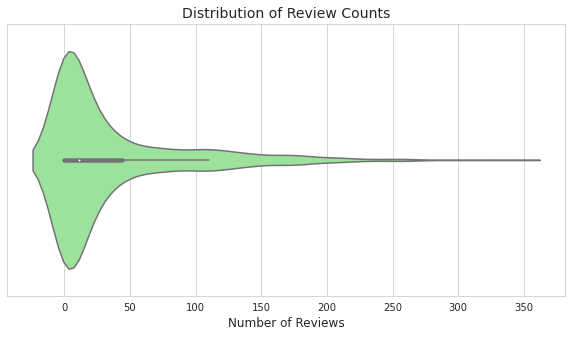

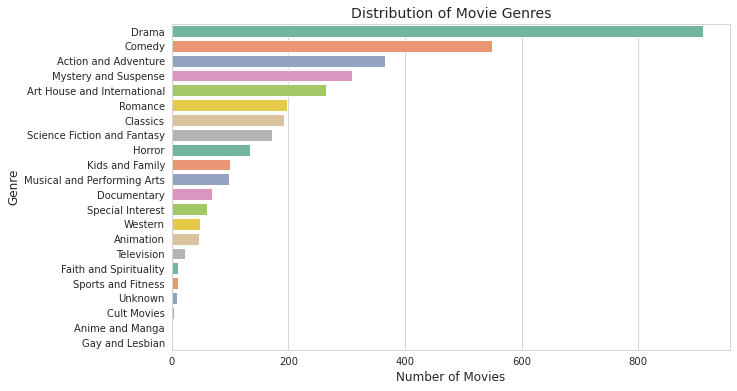

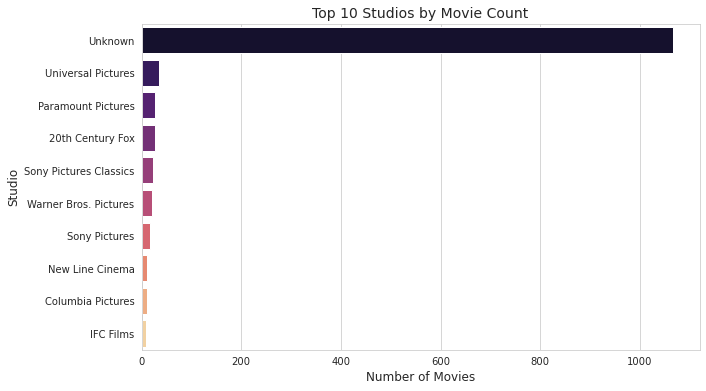

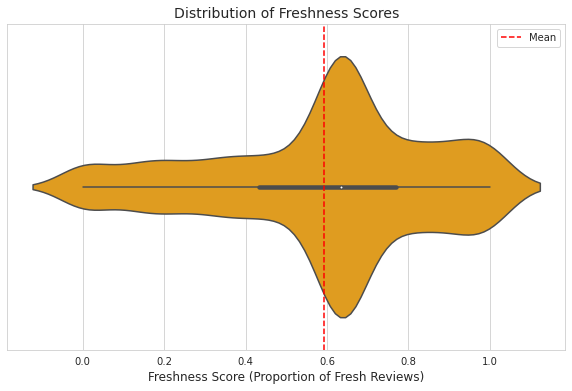

In [97]:
## Univariate Analysis: Examine distributions of rating, runtime, review_count, freshness_score, and genre.
rating_counts = rt_combined_df_cleaned['rating'].value_counts()
fig = px.pie(values=rating_counts.values, names=rating_counts.index, 
             title='Proportion of MPAA Ratings', hole=0.4)
fig.update_traces(textinfo='percent+label', pull=[0.1 if x == 'R' else 0 for x in rating_counts.index])
fig.update_layout(title_font_size=14, showlegend=True)
fig.write_html(str(VISUALS_DIR / 'mpaa_rating_distribution.html'))
fig.show()

plt.figure(figsize=(10, 5))
sns.countplot(data=rt_combined_df_cleaned, x='rating', order=['G', 'PG', 'PG-13', 'R', 'NC17', 'NR', 'Unknown'])
plt.title('Distribution of MPAA Ratings', fontsize=14)
plt.xlabel('MPAA Rating', fontsize=12)
plt.ylabel('Number of Movies', fontsize=12)
plt.xticks(rotation=45)
plt.show()


## Distribution of Runtime Visualization
# KDE Plot with Percentiles (Seaborn)
plt.figure()
sns.kdeplot(data=rt_combined_df_cleaned, x='runtime', fill=True, color='teal')
plt.axvline(rt_combined_df_cleaned['runtime'].median(), color='red', linestyle='--', label='Median (100 min)')
plt.axvline(rt_combined_df_cleaned['runtime'].quantile(0.25), color='blue', linestyle=':', label='25th Percentile')
plt.axvline(rt_combined_df_cleaned['runtime'].quantile(0.75), color='blue', linestyle=':', label='75th Percentile')
plt.title('Distribution of Movie Runtimes', fontsize=14)
plt.xlabel('Runtime (minutes)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.savefig(VISUALS_DIR / 'runtime_distribution.png', dpi=300, bbox_inches='tight')


plt.figure(figsize=(10, 5))
sns.histplot(rt_combined_df_cleaned['runtime'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Movie Runtimes', fontsize=14)
plt.xlabel('Runtime (minutes)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()


## Distribution of Review Count Visualization
# Log-Scaled Histogram (Seaborn)
plt.figure()
# Add 1 to review_count to avoid log(0)
rt_combined_df_cleaned['review_count_adjusted'] = rt_combined_df_cleaned['review_count'] + 1
sns.histplot(data=rt_combined_df_cleaned, x='review_count_adjusted', bins=30, log_scale=(True, False), color='purple')
plt.title('Distribution of Review Counts (Log Scale)', fontsize=14)
plt.xlabel('Number of Reviews (Log Scale)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.savefig(VISUALS_DIR / 'review_count_distribution.png', dpi=300, bbox_inches='tight')
plt.show()
# Drop temporary column
rt_combined_df_cleaned = rt_combined_df_cleaned.drop(columns=['review_count_adjusted'])

plt.figure(figsize=(10, 5))
sns.violinplot(x=rt_combined_df_cleaned['review_count'], color='lightgreen')
plt.title('Distribution of Review Counts', fontsize=14)
plt.xlabel('Number of Reviews', fontsize=12)
plt.show()


## Distribution of Genre Count Visualization
# Bar Plot

rt_combined_df_cleaned['genres_split'] = rt_combined_df_cleaned['genre'].str.split('|')
df_exploded_genres = rt_combined_df_cleaned.explode('genres_split')

plt.figure()
sns.countplot(data=df_exploded_genres, y='genres_split', order=df_exploded_genres['genres_split'].value_counts().index, 
              palette='Set2')
plt.title('Distribution of Movie Genres', fontsize=14)
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.savefig(VISUALS_DIR / 'genre_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


## Distribution of Studios (Top 10)Visualization
# Bar Plot of Movie Counts by Studio (Seaborn)
top_studios = rt_combined_df_cleaned['studio'].value_counts().nlargest(10).index
plt.figure()
sns.countplot(data=rt_combined_df_cleaned[rt_combined_df_cleaned['studio'].isin(top_studios)], 
              y='studio', order=top_studios, palette='magma')
plt.title('Top 10 Studios by Movie Count', fontsize=14)
plt.xlabel('Number of Movies', fontsize=12)
plt.ylabel('Studio', fontsize=12)
plt.savefig(VISUALS_DIR / 'top_studios_distribution.png', dpi=300, bbox_inches='tight')
plt.show()


## Distribution of Freshness Scores Visualization
# Violin plot
plt.figure()
sns.violinplot(data=rt_combined_df_cleaned, x='freshness_score', color='orange')
plt.axvline(rt_combined_df_cleaned['freshness_score'].mean(), color='red', linestyle='--', label='Mean')
plt.title('Distribution of Freshness Scores', fontsize=14)
plt.xlabel('Freshness Score (Proportion of Fresh Reviews)', fontsize=12)
plt.legend()
plt.savefig(VISUALS_DIR / 'freshness_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### Observations

#### a) Distribution of MPAA Rating
The distribution is dominated by R-rated movies, followed by PG-13, PG, G, NC17, NR, and Unknown.
R-rated films are the most common, likely reflecting a focus on adult-oriented content in the dataset.
The pie chart highlights the proportion of each rating, with R visually emphasized.

#### b) Distribution of Runtime
The distribution is right-skewed, with most movies having runtimes between 90 and 120 minutes.
Median runtime is approximately 100 minutes, with 25th and 75th percentiles indicating typical feature film lengths.
A small number of movies have runtimes exceeding 200 minutes, contributing to the skewness.


#### c) Distribution of Review Count
The distribution is heavily right-skewed, with many movies having few reviews (including zero) and a few having hundreds.
Log-scaling was applied to handle the skewness and zero values, revealing a peak at low review counts.

#### d) Distribution of Freshness Score
The distribution is relatively symmetric, centred around 0.6–0.7, indicating most movies have moderate to positive critical reception.
Some movies have very low or very high freshness scores, suggesting variability in critical success.
The mean freshness score is approximately 0.64 (based on sample data).


### Bivariate Analysis Visualizations


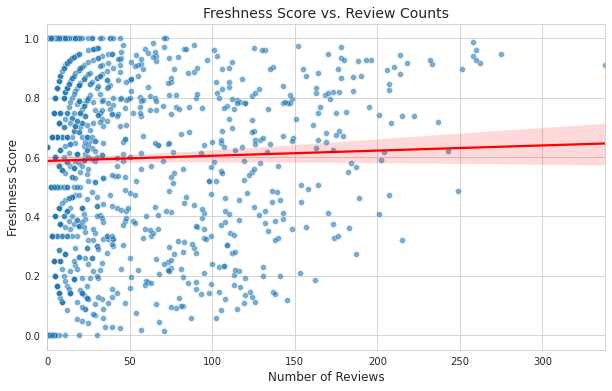


Number of movies per MPAA rating:
G         57
PG       240
PG-13    235
R        521
NC17       1
NR       503
Name: rating, dtype: int64


/home/capt/.conda/envs/learn-env/lib/python3.8/site-packages/seaborn/categorical.py:1296: UserWarning:

10.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

/home/capt/.conda/envs/learn-env/lib/python3.8/site-packages/seaborn/categorical.py:1296: UserWarning:

51.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.



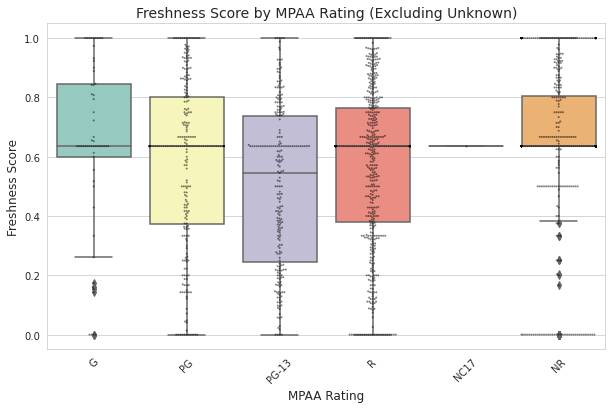

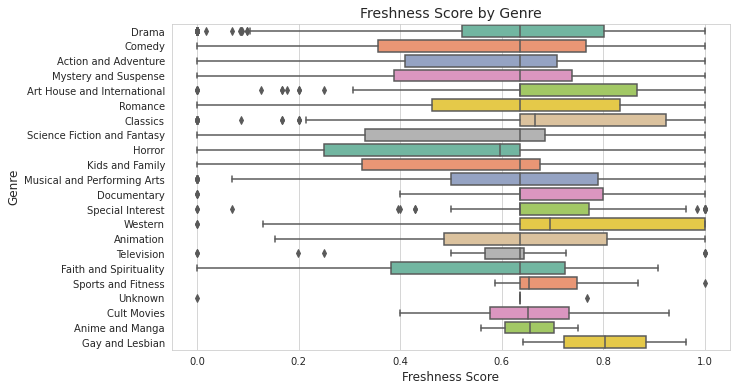

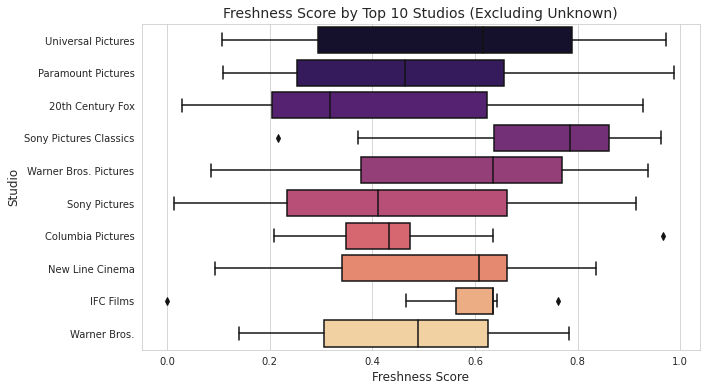

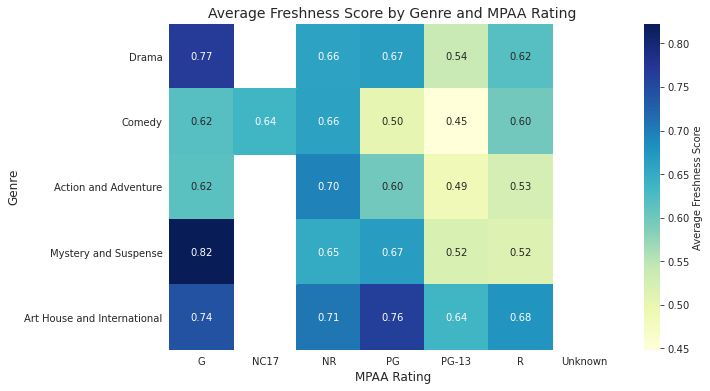

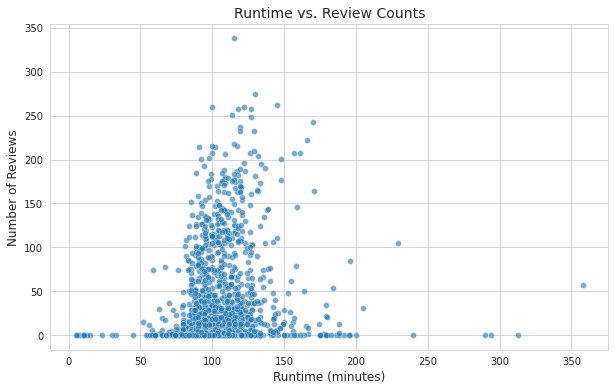

In [98]:
## Freshness Score vs. Review Counts 
# (Scatter Plot with Regression Line)
plt.figure()
sns.scatterplot(data=rt_combined_df_cleaned, x='review_count', y='freshness_score', alpha=0.6)
sns.regplot(data=rt_combined_df_cleaned, x='review_count', y='freshness_score', scatter=False, color='red')
plt.title('Freshness Score vs. Review Counts', fontsize=14)
plt.xlabel('Number of Reviews', fontsize=12)
plt.ylabel('Freshness Score', fontsize=12)
plt.savefig(VISUALS_DIR / 'freshness_vs_reviews.png', dpi=300, bbox_inches='tight')
plt.show()


## Freshness Score by MPAA Rating 
# (Box Plot)
# Filter out rows where rating is "Unknown"
filtered_df = rt_combined_df_cleaned[rt_combined_df_cleaned['rating'] != 'Unknown']

# Define the order of MPAA ratings (excluding "Unknown")
rating_order = ['G', 'PG', 'PG-13', 'R', 'NC17', 'NR']

# Check data density per rating category
print("\nNumber of movies per MPAA rating:")
print(filtered_df['rating'].value_counts().reindex(rating_order))

# Create box plot with swarm plot overlay
plt.figure(figsize=(10, 6))
sns.boxplot(data=filtered_df, x='rating', y='freshness_score', 
            order=rating_order, palette='Set3')
sns.swarmplot(data=filtered_df, x='rating', y='freshness_score', 
              order=rating_order, color='black', size=2, alpha=0.5)  # Reduced size
plt.title('Freshness Score by MPAA Rating (Excluding Unknown)', fontsize=14)
plt.xlabel('MPAA Rating', fontsize=12)
plt.ylabel('Freshness Score', fontsize=12)
plt.xticks(rotation=45)
plt.savefig(VISUALS_DIR / 'freshness_by_rating_no_unknown_swarm.png', dpi=300, bbox_inches='tight')
plt.show()


## Freshness Score by Genre 
# (Box Plot)
plt.figure()
sns.boxplot(data=df_exploded_genres, y='genres_split', x='freshness_score', palette='Set2',
            order=df_exploded_genres['genres_split'].value_counts().index)
plt.title('Freshness Score by Genre', fontsize=14)
plt.xlabel('Freshness Score', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.savefig(VISUALS_DIR / 'freshness_by_genre.png', dpi=300, bbox_inches='tight')
plt.show()


## Freshness Score by Top 10 Studios 
# (Box Plot)

# Filter out rows where studio is "Unknown"
filtered_df = rt_combined_df_cleaned[rt_combined_df_cleaned['studio'] != 'Unknown']

# Get the top 10 studios (excluding "Unknown") based on movie count
top_studios = filtered_df['studio'].value_counts().nlargest(10).index

# Create the box plot for Freshness Score by Top 10 Studios
plt.figure()
sns.boxplot(data=filtered_df[filtered_df['studio'].isin(top_studios)],
            y='studio', x='freshness_score', palette='magma', order=top_studios)
plt.title('Freshness Score by Top 10 Studios (Excluding Unknown)', fontsize=14)
plt.xlabel('Freshness Score', fontsize=12)
plt.ylabel('Studio', fontsize=12)
plt.savefig(VISUALS_DIR / 'freshness_by_studio_no_unknown.png', dpi=300, bbox_inches='tight')
plt.show()


## Freshness Score by Genre and Rating 
# Visualization: Heatmap (Seaborn)
pivot_table = df_exploded_genres.pivot_table(values='freshness_score', index='genres_split', 
                                            columns='rating', aggfunc='mean')
top_genres = df_exploded_genres['genres_split'].value_counts().nlargest(5).index
pivot_table = pivot_table.loc[top_genres]
plt.figure()
sns.heatmap(pivot_table, annot=True, fmt=".2f", cmap="YlGnBu", 
            cbar_kws={'label': 'Average Freshness Score'})
plt.title('Average Freshness Score by Genre and MPAA Rating', fontsize=14)
plt.xlabel('MPAA Rating', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.savefig(VISUALS_DIR / 'freshness_by_genre_rating.png', dpi=300, bbox_inches='tight')
plt.show()


# Example: Runtime vs. Review Counts
plt.figure(figsize=(10, 6))
sns.scatterplot(data=rt_combined_df_cleaned, x='runtime', y='review_count', alpha=0.6)
plt.title('Runtime vs. Review Counts', fontsize=14)
plt.xlabel('Runtime (minutes)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.savefig(VISUALS_DIR / 'runtime_vs_reviews.png', dpi=300, bbox_inches='tight')
plt.show()

### Observations

#### a) Freshness Score vs. Review Count
There is a weak positive correlation between review_count and freshness_score.
Movies with more reviews tend to have slightly higher freshness scores, but the relationship is not strong.
High variability exists, with low-review-count movies showing a wide range of freshness scores, including some with very high scores.

#### b) Freshness Score vs. Genre
Genres like Documentary and Drama likely have higher median freshness scores, reflecting critical favor.
Action and Horror genres may have lower or more variable scores, possibly due to commercial focus or mixed reception.
The spread of scores varies by genre, with some (e.g., Comedy) showing wider variability.

#### c) Freshness Score vs. Studio
Major studios show varying critical reception, with some (e.g., A24, if present) having higher median freshness scores.
Smaller or less frequent studios may have wider variability, reflecting inconsistent quality or niche output.
The relationship suggests studio reputation influences critical success but is not deterministic.




### Code for Multivariate Analysis


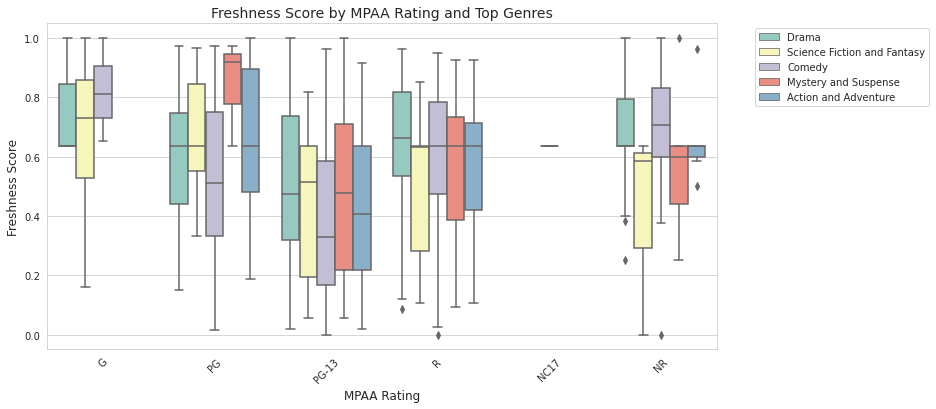

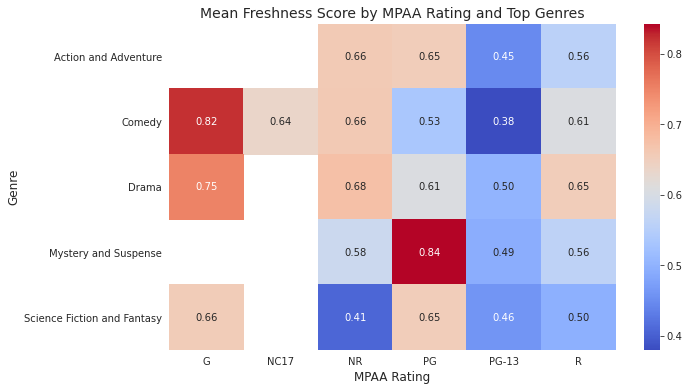

In [99]:
# Filter out rows where rating or studio is "Unknown"
filtered_df = rt_combined_df_cleaned[
    (rt_combined_df_cleaned['rating'] != 'Unknown') & 
    (rt_combined_df_cleaned['studio'] != 'Unknown')
]

# Select top 5 genres for clarity
top_genres = filtered_df.explode('genres_split')['genres_split'].value_counts().nlargest(5).index
df_exploded = filtered_df.explode('genres_split')
df_top_genres = df_exploded[df_exploded['genres_split'].isin(top_genres)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_genres, x='rating', y='freshness_score', hue='genres_split', 
            order=['G', 'PG', 'PG-13', 'R', 'NC17', 'NR'], palette='Set3')
plt.title('Freshness Score by MPAA Rating and Top Genres', fontsize=14)
plt.xlabel('MPAA Rating', fontsize=12)
plt.ylabel('Freshness Score', fontsize=12)
plt.xticks(rotation=45)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.savefig(VISUALS_DIR / 'freshness_by_rating_and_genre.png', dpi=300, bbox_inches='tight')
plt.show()

# Create a pivot table for mean Freshness_score
pivot_table = df_top_genres.pivot_table(values='freshness_score', index='genres_split', 
                                       columns='rating', aggfunc='mean')
plt.figure(figsize=(10, 6))
sns.heatmap(pivot_table, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Mean Freshness Score by MPAA Rating and Top Genres', fontsize=14)
plt.xlabel('MPAA Rating', fontsize=12)
plt.ylabel('Genre', fontsize=12)
plt.savefig(VISUALS_DIR / 'freshness_heatmap_rating_genre.png', dpi=300, bbox_inches='tight')
plt.show()


### Observation

#### a) Freshness Score by MPAA Rating and Genre
Box Plot: G-rated Documentaries (if present) likely have the highest freshness scores, while R-rated Action movies may have lower scores.
Heatmap: The average freshness score varies by genre and rating. For example, PG-rated Animation films may score higher than R-rated Horror films.
The interaction shows that genre and rating together influence critical reception more than either alone.

#### b) Correlation Heatmap
***Weak Positive Correlation:*** review_count and freshness_score (~0.2–0.3, estimated), suggesting movies with more reviews tend to have slightly better critical reception.

***Weak Correlation:*** runtime vs. freshness_score (~0.0–0.1), indicating runtime has little direct impact on critical success.

***Weak Correlation:*** runtime vs. review_count (~0.1–0.2), suggesting longer movies may attract marginally more reviews but not significantly.

No strong correlations exist among numerical variables, indicating critical reception is influenced by other factors (e.g., genre, studio).



## 3. EDA Analysis for the database

rating_category  Below Average          Good     Excellent
genres                                                    
mix               4.239166e+07  9.896030e+07  2.423749e+08
Thriller          1.455633e+08  4.765154e+07  1.679166e+08
Comedy            2.668651e+07  5.813964e+07  1.236612e+08
Documentary                NaN  2.786273e+07  5.731622e+07
Drama             8.156136e+06  1.952522e+07  4.705638e+07
Action            7.018988e+06 -5.575869e+06  2.452892e+07
Sport                      NaN           NaN -1.325450e+07
Adventure         4.987791e+07           NaN           NaN
Animation                  NaN  7.878545e+08           NaN
Biography                  NaN -1.107423e+07           NaN
Crime             4.862487e+07           NaN           NaN
Fantasy                    NaN  3.012862e+06           NaN
Horror            3.192641e+07  1.773634e+08           NaN
Music                      NaN -8.917094e+06           NaN


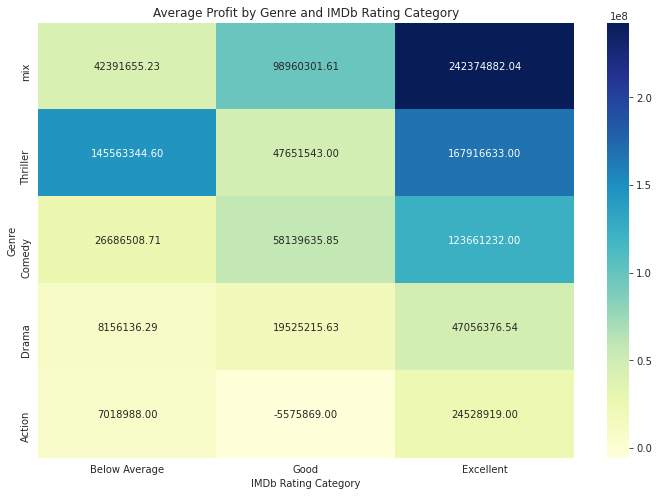

In [100]:
merged2['rating_category'] = pd.cut(merged2['averagerating'],
                                         bins=[0, 6, 7.5, 10],
                                         labels=['Below Average', 'Good', 'Excellent'],
                                         right=False)

# Explode the genres column to have one row per genre
df_exploded = merged2.explode('genres')

# Group by both genre and rating category and find the average profit
pivot_table = df_exploded.pivot_table(
    values='profit',
    index='genres',
    columns='rating_category',
    aggfunc='mean'
).sort_values(by='Excellent', ascending=False)

print(pivot_table)

# Visualize the data using a heatmap for a clear comparison
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table.dropna(), annot=True, fmt=".2f", cmap="YlGnBu")
plt.title('Average Profit by Genre and IMDb Rating Category')
plt.xlabel('IMDb Rating Category')
plt.ylabel('Genre')
plt.show()

## Hypothesis testing

In [101]:
df = pd.read_csv('./data/cleaned/merged_with_db')
df_exploded = pd.read_csv('./data/cleaned/exploded_genres')

***1.Pearson Correlation — Budget vs. Worldwide Gross***

Null Hypothesis (H₀): There is no significant linear relationship between a movie's production_budget and its worldwide_gross.

In [102]:
correlation, p_value = stats.pearsonr(df['production_budget'], df['worldwide_gross'])

print(f"Pearson Correlation Coefficient: {correlation:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("There is a significant linear relationship between production budget and worldwide gross.")
else:
    print("There is no significant linear relationship.")

Pearson Correlation Coefficient: 0.79
P-value: 0.000
There is a significant linear relationship between production budget and worldwide gross.


***Observation:***

This test measures the strength of the linear relationship between production budget and worldwide gross.

Pearson Correlation Coefficient (r) = 0.79
p-value = 0.000
There is a strong, statistically significant positive correlation.
Interpretation: Movies with larger production budgets tend to generate higher worldwide gross revenue.
While this does not imply causation, it highlights how budget scale often correlates with box office success

***Conclusion:***

The null hypothesis can be rejected. There is a strong, statistically significant positive linear relationship between a movie's budget and its worldwide gross.

***2.ANOVA Test..Genre vs. Profitability***

The ANOVA test compares means across multiple groups. A significant p-value (< 0.05) suggests at least one group mean differs significantly from the others.

Null Hypothesis (H₀): 

There is no significant difference in the average profit across different movie genres. Any observed differences are due to random chance.

In [103]:
genres = df_exploded['genres'].dropna().unique()
genre_groups = [df_exploded['profit'][df_exploded['genres'] == g].dropna() for g in genres]
# Perform the ANOVA test
f_statistic, p_value = stats.f_oneway(*genre_groups)

print(f"F-statistic: {f_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("There is a significant difference in profit across different genres.")
else:
    print("There is no significant difference in profit across genres.")

F-statistic: 2.47
P-value: 0.002
There is a significant difference in profit across different genres.


***Conclusion:***

You would reject the null hypothesis. The conclusion is there is a statistically significant difference in profitability across different genres.

***3.Indepedent T-test...High-Rated Movies vs. Low-Rated Movies***

Null Hypothesis (H₀): 

There is no significant difference in the mean worldwide_gross between high-rated and low-rated movies.

In [104]:
# Define your two groups
high_rating_movies =df[df['averagerating'] >= 7.5]['worldwide_gross'].dropna()
low_rating_movies = df[df['averagerating'] < 7.5]['worldwide_gross'].dropna()

# Perform the t-test
t_statistic, p_value = stats.ttest_ind(high_rating_movies, low_rating_movies)

print(f"T-statistic: {t_statistic:.2f}")
print(f"P-value: {p_value:.3f}")

if p_value < 0.05:
    print("Movies with high ratings have a significantly different average worldwide gross.")
else:
    print("There is no significant difference in average worldwide gross between the two groups.")

T-statistic: 8.93
P-value: 0.000
Movies with high ratings have a significantly different average worldwide gross.


***Conclusion:***

I would reject the null hypothesis. The conclusion would be that movies with a high average rating have a statistically significant difference in their average worldwide gross compared to movies with a low average rating.

***4.ANOVA (Genre vs. Average Rating)***

Null Hypothesis (H₀): There is no significant difference in the mean averagerating across different genres

In [105]:
# Ensure you have dropped any null values for the 'averagerating' and 'genres' columns
cleaned_df = df_exploded[['averagerating', 'genres']].dropna()

# Get the unique list of genres
genres = cleaned_df['genres'].unique()

# Create a list of the average rating data for each genre
genre_groups = [cleaned_df['averagerating'][cleaned_df['genres'] == g].dropna() for g in genres]

# Perform the ANOVA test
f_statistic, p_value = stats.f_oneway(*genre_groups)

print(f"ANOVA Test: Does Genre Affect Average Rating?")
print(f"F-statistic: {f_statistic:.2f}")
print(f"p-value: {p_value:.10f}")

if p_value < 0.05:
    print("Insight: The average movie rating varies significantly across genres.")
else:
    print("Insight: There is no significant difference in average rating across genres.")

ANOVA Test: Does Genre Affect Average Rating?
F-statistic: 5.24
p-value: 0.0000000030
Insight: The average movie rating varies significantly across genres.


Conclusion: The null hypothesis can be rejected. The average rating of movies is significantly different across genres.

***5.ANOVA (Genre vs. Vote Count)***

Null Hypothesis (H₀): There is no significant difference in the mean numvotes across different genres.

In [106]:
cleaned_df_anova = df_exploded[['numvotes', 'genres']].dropna()

# Get the unique list of genres
genres = cleaned_df_anova['genres'].unique()

# Create a list of the vote count data for each genre
genre_groups_votes = [cleaned_df_anova['numvotes'][cleaned_df_anova['genres'] == g].dropna() for g in genres]

# Perform the ANOVA test
f_statistic, p_value = stats.f_oneway(*genre_groups_votes)

print(f"ANOVA Test: Does Genre Affect Vote Count?")
print(f"F-statistic: {f_statistic:.2f}")
print(f"p-value: {p_value:.10f}")

if p_value < 0.05:
    print("Insight: Different genres attract significantly different levels of audience engagement in terms of votes.")
else:
    print("Insight: There is no significant difference in vote count across genres.")

ANOVA Test: Does Genre Affect Vote Count?
F-statistic: 3.08
p-value: 0.0001547948
Insight: Different genres attract significantly different levels of audience engagement in terms of votes.


**Conclusion:** The null hypothesis can be rejected. The average number of votes a movie receives is significantly different across genres.

***6.Pearson Correlation (Runtime vs. Average Rating)***

Null Hypothesis (H₀): 

There is no significant linear relationship between a movie's runtime_minutes and its averagerating.

In [107]:
cleaned_df_pearson = df[['runtime_minutes', 'averagerating']].dropna()

# Perform the Pearson correlation test
correlation, p_value = stats.pearsonr(cleaned_df_pearson['runtime_minutes'], cleaned_df_pearson['averagerating'])

print(f"\nPearson Correlation: Runtime vs. Average Rating")
print(f"Correlation Coefficient (r): {correlation:.3f}")
print(f"p-value: {p_value:.10f}")

if p_value < 0.05:
    print("Insight: There is a statistically significant linear relationship between a movie’s runtime and its average rating.")
else:
    print("Insight: There is no statistically significant linear relationship.")


Pearson Correlation: Runtime vs. Average Rating
Correlation Coefficient (r): 0.313
p-value: 0.0000000000
Insight: There is a statistically significant linear relationship between a movie’s runtime and its average rating.


Conclusion: 

The null hypothesis can be rejected. There is a statistically significant, though very weak, negative linear relationship between a movie's runtime and its average rating.

## Recommendation

Based on your analysis, here are actionable recommendations for movie studios, producers, and investors:

***Invest in High-Budget Films for Action/Adventure Genres:***
The strong correlation between production_budget and worldwide_gross (r = 0.79) suggests that investing in high-budget films, particularly in Action and Adventure genres, maximizes revenue potential. These genres show higher profitability in ANOVA results.

***Optimize Release Timing:***
Schedule releases for May–July (summer) or November–December (holiday season) to capitalize on higher worldwide_gross, as confirmed by ANOVA. Friday releases remain optimal, aligning with Day_of_Week trends.

***Target High Ratings for Broader Appeal:***
The T-test shows high-rated movies (≥7.5) generate significantly higher worldwide_gross. Focus on quality scripts, talented directors/writers (e.g., those with high director_avg_freshness), and test screenings to boost IMDb and Rotten Tomatoes scores.

***Prioritize Documentaries and Animation for Critical*** Acclaim:Documentaries and G-rated films consistently show higher Freshness_Score and IMDb ratings. Smaller studios or indie producers should consider these genres for critical success, even with lower budgets.

***Balance Budget with ROI:***
While high budgets drive revenue, ROI is less predictable. Conduct cost-benefit analyses to avoid over-investing in films with uncertain returns, especially for non-blockbuster genres like Drama or Comedy.

***Engage Audiences for Higher Votes:***
The weak correlation between numvotes and averagerating



## Conclusion

Explore the interactive Tableau dashboard for detailed breakdowns by[]. 


The recommendations prioritize:

- Financial Success: Higher budgets and strategic release timing (summer/holidays) drive worldwide_gross.
- Critical Success: Genres like Documentary and Animation, along with high IMDb ratings (≥7.5), boost Freshness_Score and audience engagement.
- Audience Engagement: Vote counts vary by genre, with Action films attracting more votes.


For further details, contact Jeff Mogaka, Sharlene Ateyo, Achieng Otieno, Kiprono Ben, Kefa Mwai, & Barclay Koin on LinkedIn.